https://www.kaggle.com/datasets/warcoder/earthquake-dataset?select=earthquake_1995-2023.csv

I need to do an appendix for my references?

In [1976]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

### Dataset Background and Source

The **Earthquake dataset** was created using data from the **United States Geological Survey (USGS)**, an organization that compiles global seismic event information. This information was gathered via the earthquake catalog API provided by USGS.

This dataset was collected to support research in **earthquake analysis**, **tsunami risk prediction**, and **seismic hazard assessment**, representing **782 significant earthquakes worldwide** between **2001 and 2022**.

Its objective is to **capture and reflect globally monitored seismic activity**, making it a valuable resource within the **environmental and geophysical sciences** domain.

You can access the dataset here: [Kaggle — Earthquake dataset](https://www.kaggle.com/datasets/warcoder/earthquake-dataset?select=earthquake_data.csv)

The dataset has a total of 782 samples, each representing a significant earthquake event, with 19 features (columns) describing various attributes of these events.

#### My goal is to build a predictive model that can accurately predict the likelihood of a tsunami occurring after an earthquake event based on the characteristics of the earthquake.

### Feature Overview

| Column       | Description                                                                                                                                            |
|--------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| title        | Title name given to the earthquake                                                                                                                     |
| magnitude    | The magnitude of the earthquake                                                                                                                        |
| date_time    | Date and time                                                                                                                                          |
| cdi          | The maximum reported intensity for the event range                                                                                                     |
| mmi          | The maximum estimated instrumental intensity for the event                                                                                             |
| alert        | The alert level - “green”, “yellow”, “orange”, and “red”                                                                                                |
| tsunami      | "1" for events in oceanic regions and "0" otherwise                                                                                                     |
| sig          | A number describing how significant the event is. Larger numbers indicate a more significant event. This value is determined by magnitude, maximum MMI, felt reports, and estimated impact |
| net          | The ID of a data contributor. Identifies the network considered to be the preferred source of information for this event.                               |
| nst          | The total number of seismic stations used to determine earthquake location.                                                                            |
| dmin         | Horizontal distance from the epicenter to the nearest station                                                                                          |
| gap          | The largest azimuthal gap between azimuthally adjacent stations (in degrees). Smaller numbers indicate more reliable positions. Gaps >180° have large uncertainties |
| magType      | The method or algorithm used to calculate the preferred magnitude for the event                                                                       |
| depth        | The depth where the earthquake begins to rupture                                                                                                        |
| latitude     | Latitude coordinate of the earthquake                                                                                                                  |
| longitude    | Longitude coordinate of the earthquake                                                                                                                 |
| location     | Location within the country                                                                                                                            |
| continent    | Continent of the earthquake-hit country                                                                                                                |
| country      | Affected country                                                                                                                                       |

Chauhan, C. (2024) *Earthquake dataset*. Available at: https://www.kaggle.com/datasets/warcoder/earthquake-dataset?select=earthquake_data.csv (Accessed: 24 October 2025).



### Expected Relationships between Features

These relationship are assumed based on geophysical principles related to earthquake and tsunami generation not any EDA of the dataset itself.

----
- **Relationships between Magnitude and Intensity Variables**
  - Variables: `magnitude`, `cdi`, `mmi`, `sig`
  - Relationship: Higher magnitude earthquakes tend to produce stronger shaking (`cdi`, `mmi`) and higher significance scores (`sig`).

- **Relationship between Depth and Intensity/Tsunami**
  - Variables: `depth`, `cdi`, `mmi`, `tsunami`
  - Relationship: Shallower earthquakes usually cause stronger surface shaking and are more likely to generate tsunamis.

- **Relationships among Seismic Station Metrics**
  - Variables: `nst`, `dmin`, `gap`
  - Relationship: More seismic stations typically result in smaller gaps and shorter distances to the nearest station, improving location accuracy.

- **Relationships between Geographic Features**
  - Variables: `latitude`, `longitude`, `country`, `continent`
  - Relationship: Earthquakes cluster geographically; certain regions may experience higher magnitudes or more frequent events.

- **Relationships between Alert Level and Event Characteristics**
  - Variables: `alert`, `magnitude`, `cdi`, `mmi`, `sig`
  - Relationship: Higher magnitude and intensity events usually correspond to higher alert levels.

- **Relationships involving Tsunami Occurrence**
  - Variables: `tsunami`, `magnitude`, `depth`, `latitude`, `longitude`
  - Relationship: Strong, shallow, and oceanic earthquakes are more likely to trigger tsunamis.

OpenAI, 2025. ChatGPT (GPT-5) [online] query: `given common geological and domain knowledge, which of the following: ```{my dataframe columns}``` are likely to be highly correlated?. Available at: <https://chat.openai.com/> [Accessed 24 October 2025].



Importing the dataset from the CSV file and loading it into a pandas DataFrame for analysis and modeling.

In [1977]:
df = pd.read_csv('data/earthquake_data.csv')


### Data summary and initial exploration:

Lets visualize the distribution of each feature using histograms to get a sense of their distributions, ranges, and potential outliers.

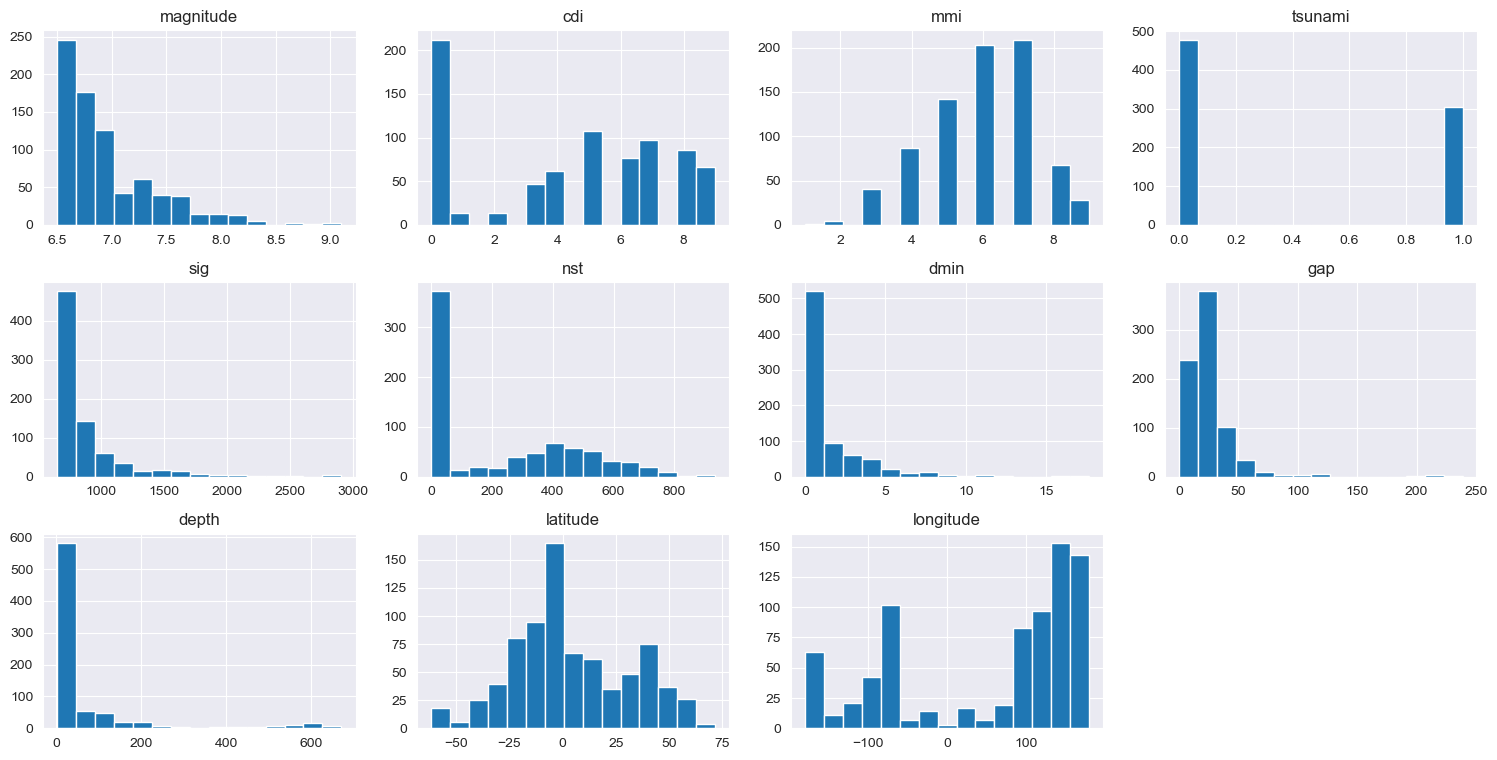

In [1978]:
df.hist(bins=15, figsize=(15,10), layout=(4,4))
plt.tight_layout()
plt.show()

A few things to note from these histograms:
- tsunami is a binary variable with most values being 0 (no tsunami).
- left skewed distributions appear common for `magnitude, sig, cdi, mmi, nst, dmin, gap, and depth.`
    - based on our domain knowledge and these histograms distributions, it appears most earthquakes in this dataset are of lower magnitude and general impact with a smaller collection of high magnitude, high impact events, these are likely the significant earthquakes.

Some random samples from the dataset to get a feel for the data, its structure, and the types of values present.

In [1979]:
df.sample(16)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
371,"M 6.8 - 62 km WSW of Panguna, Papua New Guinea",6.8,16-10-2013 10:30,0,6,green,1,711,us,0,5.790,9.0,mww,35.00,-6.4456,154.9310,"Panguna, Papua New Guinea",NaN,Papua New Guinea
163,"M 7.9 - 45 km S of Levuka, Fiji",7.9,06-09-2018 15:49,7,4,green,1,979,us,0,1.431,12.0,mww,670.81,-18.4743,179.3500,"Levuka, Fiji",NaN,Fiji
386,M 7.3 - South Sandwich Islands region,7.3,15-07-2013 14:03,0,6,green,1,820,us,398,0.000,43.0,mww,11.00,-60.8570,-25.0700,South Sandwich Islands region,NaN,United Kingdom of Great Britain and Northern Ireland (the)
166,"M 7.1 - 136 km W of Iñapari, Peru",7.1,24-08-2018 09:04,0,3,green,0,776,us,0,3.770,12.0,mww,630.00,-11.0355,-70.8284,"Iñapari, Peru",South America,Peru
759,"M 7.5 - 155 km E of Kendari, Indonesia",7.5,19-10-2001 03:28,0,6,NaN,0,865,us,234,0.000,0.0,mwc,33.00,-4.1020,123.9070,"Kendari, Indonesia",NaN,Indonesia
583,"M 6.8 - 82 km NNE of Antofagasta, Chile",6.8,15-11-2007 15:05,6,7,NaN,0,716,us,285,0.000,40.1,mwc,26.00,-22.9250,-70.2370,Ant,South America,Chile
72,"M 6.6 - 171 km SSE of Ust’-Kamchatsk Staryy, Russia",6.6,16-03-2021 18:38,5,5,green,1,672,us,0,3.183,18.0,mww,13.23,54.7018,163.2080,"Ust’-Kamchatsk Staryy, Russia",NaN,NaN
382,"M 7.0 - 101 km SW of Atka, Alaska",7.0,30-08-2013 16:25,5,6,green,0,758,us,0,0.624,53.0,mww,29.00,51.5370,-175.2300,"Atka, Alaska",NaN,NaN
704,"M 6.5 - 4 km NW of Can-Avid, Philippines",6.5,18-11-2003 17:14,0,6,NaN,0,650,us,487,0.000,45.9,mwb,35.00,12.0250,125.4160,"Can-Avid, Philippines",NaN,Philippines
40,"M 7.3 - 125 km NNE of Lospalos, Timor Leste",7.3,29-12-2021 18:25,8,7,green,0,921,us,0,3.713,19.0,mww,165.49,-7.5924,127.5810,"Lospalos, Timor Leste",NaN,Indonesia


This large sample shows us clearly the different data types present in the dataset, including numerical, categorical, and datetime features.

#### Statistical Summary

A general statistical overview of the dataset including measures like ```mean, standard deviation, min, max, and quartiles``` for each numerical feature.

In [1980]:
df.describe()

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,0.388747,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199
std,0.445514,3.169939,1.462724,0.487778,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886
min,6.500000,0.000000,1.000000,0.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000
25%,6.600000,0.000000,5.000000,0.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050
50%,6.800000,5.000000,6.000000,0.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000
75%,7.100000,7.000000,7.000000,1.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000
max,9.100000,9.000000,9.000000,1.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000


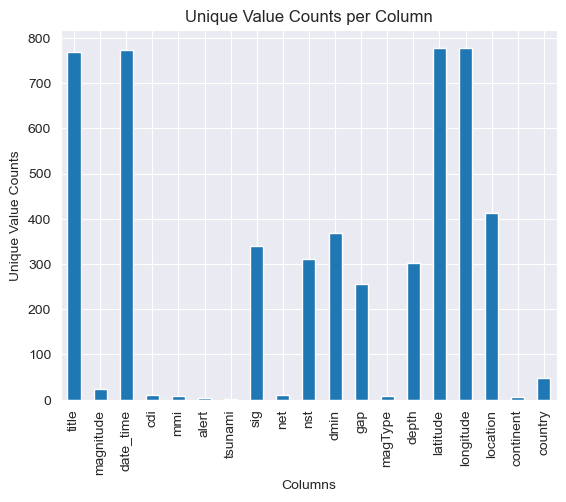

In [1981]:
df.nunique(axis=0).plot(kind='bar')
plt.title('Unique Value Counts per Column')
plt.xlabel('Columns')
plt.ylabel('Unique Value Counts')
plt.show()

### Data Types

Checking the data types of each feature to understand the nature of the data, whether they are numerical or categorical.

If they are categorical, we would need to consider encoding them into a numerical form for modeling purposes.

In [1982]:
print(df.dtypes)

title         object
magnitude    float64
date_time     object
cdi            int64
mmi            int64
alert         object
tsunami        int64
sig            int64
net           object
nst            int64
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
location      object
continent     object
country       object
dtype: object


We have quite a mixed set of data types here:
- Numerical features: `magnitude`, `cdi`, `mmi`, `sig`, 'nst', `dmin`, `gap`, `depth`, `latitude`, `longitude`, `year`, `month`, `tsunami`
- Categorical features: `title`, `date_time`, `alert`, `net`, `magType`, `location`, `continent`, `country`
- Datetime feature: `date_time`

We going to need to convert the categorical features into numerical form using techniques like one-hot encoding or label encoding before feeding them into machine learning models. We also need to parse the `date_time` feature into datetime format and potentially extract useful temporal features (like year, month, day, hour) from it.


### Data shape

Taking a look at the shape of the dataset to understand how many samples (rows) and features (columns) we have.

Also listing out the column names for easy reference.

In [1983]:
print(f'Dataset Shape: {df.shape}')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print('Column Names:', df.columns.tolist())

Dataset Shape: (782, 19)
Rows: 782, Columns: 19
Column Names: ['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami', 'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude', 'longitude', 'location', 'continent', 'country']


We have 19 columns (features) and 782 rows (samples) in this dataset.

In [1984]:
unique_values = df.nunique()
print(f'Unique values per column:\n{unique_values}')

Unique values per column:
title        768
magnitude     24
date_time    773
cdi           10
mmi            9
alert          4
tsunami        2
sig          339
net           11
nst          312
dmin         369
gap          256
magType        9
depth        303
latitude     778
longitude    777
location     413
continent      6
country       49
dtype: int64


### Missing Values

Its important to check for any missing values in the dataset as they can impact model performance. We will check for missing values in each column and also the total number of missing values in the entire dataset.

In [1985]:
print(df.isnull().sum())

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64


In [1986]:
place_holders = [-9999, 9999, np.inf, -np.inf, 'nan', 'NaN', 'NA', 'null', 'NULL', '']
print(df.isin(place_holders).sum().sum() + df.isnull().sum().sum())

1246


So in total we have 1246 missing values across the entire dataset. We will need to handle these missing values appropriately before modeling, either by imputation or removal depending on the context and amount of missingness.

In [1987]:
#percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]
print(f'Percentage of missing values per column:\n{missing_percentage}')

Percentage of missing values per column:
alert        46.930946
location      0.639386
continent    73.657289
country      38.107417
dtype: float64


In [1988]:
missing_values_datatypes = df[missing_percentage.index].dtypes
print(f'Data types of columns with missing values:\n{missing_values_datatypes}')

Data types of columns with missing values:
alert        object
location     object
continent    object
country      object
dtype: object


In [1989]:
df[missing_percentage.index].sample(15)

,alert,location,continent,country
59,green,"Perryville, Alaska",NaN,NaN
722,NaN,"Dellys, Algeria",NaN,Algeria
113,green,"Kisante, Philippines",NaN,Philippines
364,green,"Sola, Vanuatu",NaN,Vanuatu
169,green,"Labuan Lombok, Indonesia",NaN,Indonesia
423,yellow,"Champerico, Guatemala",NaN,NaN
603,NaN,"Iztapa, Guatemala",NaN,NaN
763,NaN,"Skýros, Greece",Europe,Greece
18,green,"Azángaro, Peru",South America,Peru
475,NaN,"?arai, Japan",NaN,NaN


Object in this context refers to string/categorical data types in pandas DataFrames.

We can see when we look at the sample rows, these are missing string values (categorical data) in the columns of `alert`, `location`, `country`, and `continent`.

#### Alert missing values imputation strategy

<Axes: xlabel='alert'>

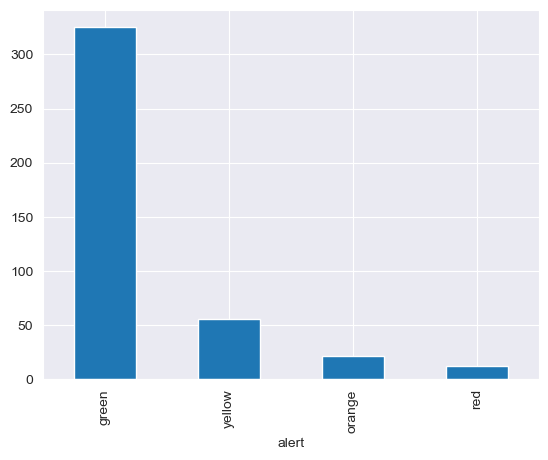

In [1990]:
#get unique values for alert column
df['alert'].value_counts().plot(kind='bar')

This plot tells us a few important things about the `alert` column:
- The most common alert level is "green", indicating low severity earthquakes.
- It has a small number of fixed categories (green, yellow, orange, red) which should make imputation easier.

If we encode the alert level from categorical to numerical, we can study it in a correlation matrix to see how other features relate to it and possibly use those relationships to impute missing alert values.

This stands to reason because alert levels are assigned based on earthquake characteristics like magnitude, intensity, and significance which are all numerical features in our dataset.

The visualization above shows that `alert` has 4 unique levels: green, yellow, orange, and red.

Strongly suggesting that this is an ordinal categorical variable where the levels have a natural order of severity.

Its clear using domain knowledge that `alert` is an ordinal categorical variable where the levels have a natural order of severity: green < yellow < orange < red. (source: https://earthquake.usgs.gov/data/pager/background.php)



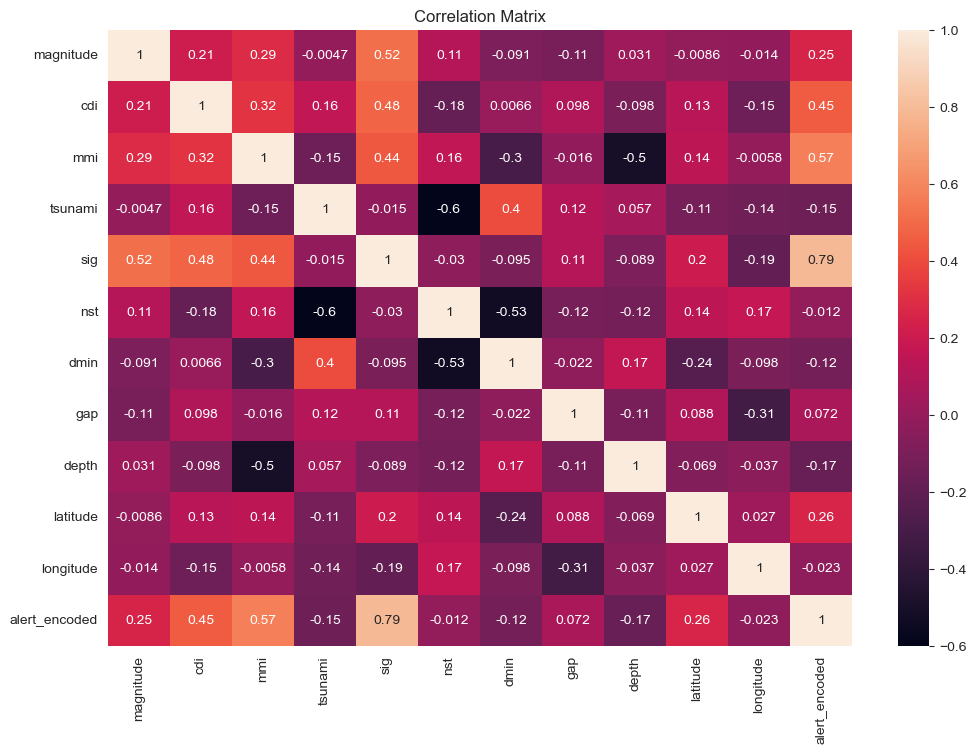

In [1991]:
#ordered encoding for alert levels
alert_order = {'green': 1, 'yellow': 2, 'orange': 3, 'red': 4}
df_temp = df.copy()
df_temp['alert_encoded'] = df_temp['alert'].map(alert_order)
numerical_cols = df_temp.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_temp[numerical_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

From studying our correlation matrix, we can see that `alert` has moderate positive correlations with `magnitude`, `cdi`, `mmi`, `nst` and `sig`.

Our strong correlation is between `alert` and `sig` (0.79). This makes sense within the domain as `sig` is a significance score that reflects the overall impact of the earthquake, which would naturally influence the alert level assigned.

Therefor, we will use `sig` correlation to impute missing, `alert` values as the correlation is strong enough to provide a reliable basis for imputation.

Using a rule based / conditional imputation strategy based on the mean `sig` value for each alert level.

In [1992]:
print(df.groupby('alert').agg({
    'sig': ['mean']
}).sig)

               mean
alert              
green    773.224615
orange  1382.136364
red     2475.000000
yellow  1047.696429


In [1993]:
alert_thresholds = df.groupby('alert').agg({
    'sig': ['mean']
}).sig

green_threshold = alert_thresholds.loc['green', 'mean'] #index by alert level, get column 'mean'
yellow_threshold = alert_thresholds.loc['yellow', 'mean']
orange_threshold = alert_thresholds.loc['orange', 'mean']
red_threshold = alert_thresholds.loc['red', 'mean']

#Order of alert levels: red, orange, yellow, green - source: https://earthquake.usgs.gov/data/pager/background.php

def impute_alert(row):
    if pd.isnull(row['alert']):
        if row['magnitude'] >= red_threshold:
            return 'red'
        elif row['magnitude'] >= orange_threshold:
            return 'orange'
        elif row['magnitude'] >= yellow_threshold:
            return 'yellow'
        else:
            return 'green'
    else:
        return row['alert']
#apply the imputation function
df['alert'] = df.apply(impute_alert, axis=1)
#verify no more missing values in alert column
print(f'Missing values in alert column after imputation: {df["alert"].isnull().sum()}')

Missing values in alert column after imputation: 0


<Axes: >

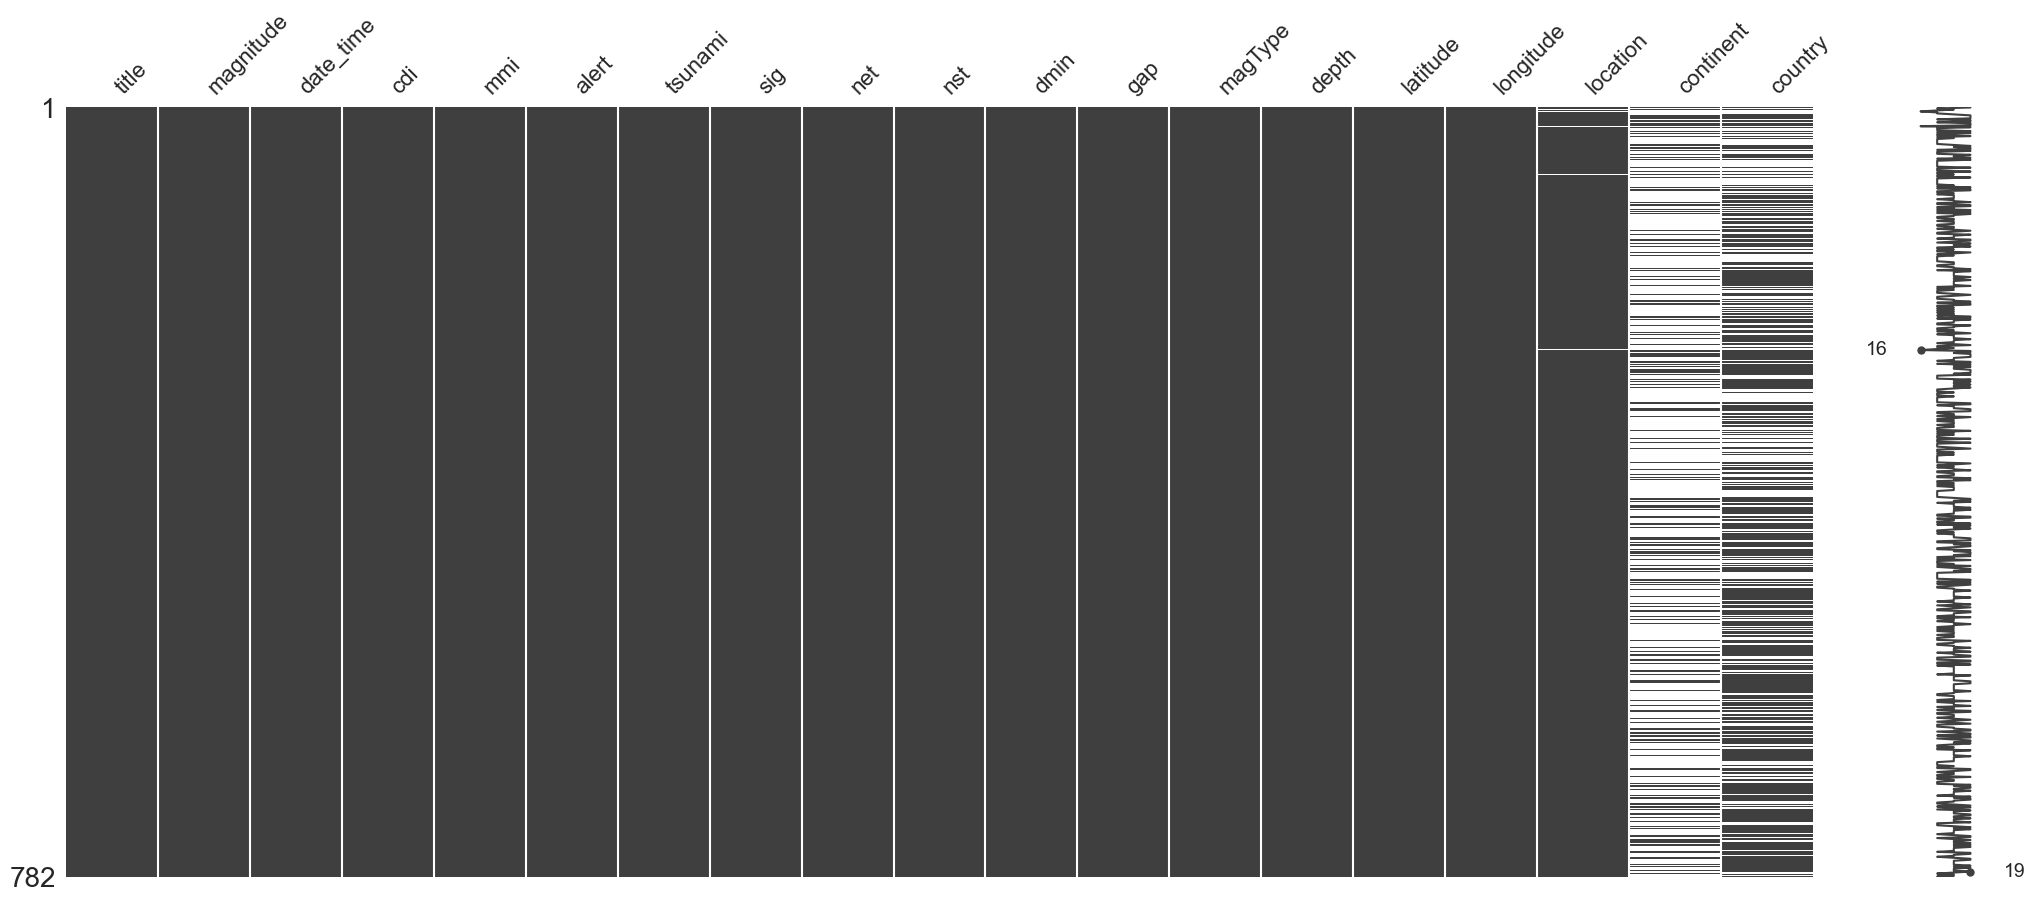

In [1994]:
msno.matrix(df)

#### Location missing values imputation strategy

Location is closely related to our `country` feature as it describes the specific area within the country where the earthquake occurred.

Our true location values will have a more precise description of the area within the country, however, using this strategy we can impute missing location values based on the country only, which is better than having no location information at all.

We can also see in the missing value visualization above that in a few instances where location is missing, we have country information available.

This is another example of rule based / conditional imputation but this time based on categorical relationship between the `location` and `country` features.



In [1995]:
print(f'Missing values in location column before imputation: {df["location"].isnull().sum()}')
def impute_location(row):
    if pd.isnull(row['location']):
        if not pd.isnull(row['country']):
            return f'{row["country"]}'
        else:
            return np.nan # cannot impute location
    else:
        return row['location']
#apply the imputation function
df['location'] = df.apply(impute_location, axis=1)
#verify no more missing values in location column
print(f'Missing values in location column after imputation: {df["location"].isnull().sum()}')

Missing values in location column before imputation: 5
Missing values in location column after imputation: 3


The remaining missing values in the location column are those where both location and country were missing, so we could not impute anything meaningful. So i will drop these rows from the dataset.

In [1996]:
df = df.dropna(subset=['location'])

In [1997]:
print(df.location.sample(15))

661             Katabu, Indonesia
683     Kirakira, Solomon Islands
485    Kandrian, Papua New Guinea
496       Kimbe, Papua New Guinea
676          Maubara, Timor Leste
709                Kushiro, Japan
602            Kashiwazaki, Japan
150              Lithakiá, Greece
776           Bengkulu, Indonesia
367                    Scotia Sea
373              Kíssamos, Greece
233         Blenheim, New Zealand
153          Port McNeill, Canada
528               Tual, Indonesia
378                Bela, Pakistan
Name: location, dtype: object


#### Country missing values imputation strategy

In [1998]:
coma_count = df['location'].str.contains(',').sum()
print(f'Percentage of locations with a comma: {(coma_count / len(df)) * 100:.2f}%')

Percentage of locations with a comma: 91.40%


We can see in the random samples above that many of the location entries contain a comma, indicating they include both a specific area and the country name (e.g., "Los Angeles, USA"). We can use this infomation to help us populate missing country values from the location column by taking the substring after the comma as the country name.

This is another example of rule based / conditional imputation based on the relationship between the `location` and `country` features.

Given the quantity of missing country values (295), replacing them with location values will introduce some multi-collinearity. However, I believe this is acceptable in this case as having some country information is better than none at all for our modeling purposes.

similarly to when we used the `country` feature to impute missing `location` values, we can use the `location` feature to impute missing `country` values, because the missing matrix shows that in many cases where `country` is missing, `location` is present.

In [1999]:
print(f'Missing values in country column before imputation: {df["country"].isnull().sum()}')
def impute_country(row):
    if pd.isnull(row['country']):
        if ',' in row['location']:
            return row['location'].split(',')[-1].strip() # extract country from location
        else:
            return np.nan # cannot impute country
    else:
        return row['country']
#apply the imputation function

#verify no more missing values in country column
df['country'] = df.apply(impute_country, axis=1)
print(f'Missing values in country column after imputation: {df["country"].isnull().sum()}')

Missing values in country column before imputation: 295
Missing values in country column after imputation: 42


In [2000]:
missing_country_locations = df[df['country'].isnull()]['location']
print(f'Locations with missing country values:\n{missing_country_locations}')

Locations with missing country values:
5                            the Fiji Islands
6                            the Fiji Islands
15                       the Kermadec Islands
22                        the Loyalty Islands
28                           the Fiji Islands
30                    Kermadec Islands region
45                             Vanuatu region
46                             Vanuatu region
52              South Sandwich Islands region
56              South Sandwich Islands region
57              South Sandwich Islands region
67                 Mauritius - Reunion region
73                    Kermadec Islands region
78                        the Loyalty Islands
85                 central Mid-Atlantic Ridge
88                 central Mid-Atlantic Ridge
97                       the Kermadec Islands
137              Prince Edward Islands region
160                          the Fiji Islands
161                   Kermadec Islands region
186                      Bouvet Island re

Looking at the 42 remaining samples without country information, we can see that a lot of these are either, small islands (fiji), semi-independent territories (Okhotsk), general oceanic regions (off the west coast of northern Sumatra) or disputed areas (the Kuril Islands).

Having looked at this data, i'm confident these values represent similar value to countries. Therefore, I will impute these missing country values with the location value itself for these specific cases.


In [2001]:
df['country'] = df['country'].fillna(df['location'])
#verify no more missing values in country column
print(f'Missing values in country column after final imputation: {df["country"].isnull().sum()}')

Missing values in country column after final imputation: 0


The quantity of data missing from the `contient` column is 73% is quite high and given that similar information can be inferred from the `country` and `location` feature, I will drop the `continent` column entirely from the dataset to avoid having to use excessive imputation which may introduce noise and inaccuracy.

In [2002]:
df = df.drop(columns=['continent'])
print(df.columns)

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'country'],
      dtype='object')


#### Visualizing missing data pattern after imputation

In [2003]:
total_missing_after = df.isnull().sum().sum()
print(f'Total missing values after imputation: {total_missing_after}')

Total missing values after imputation: 0


### Features and target identification and importance

X is our new Dataframe containing all features except the target variable `tsunami`, and y is a Series containing target variable `tsunami` which we will be predicting.

X a fully imputed feature set with no missing values, and y `tsunami` didn't have any missing values to begin with.

In [2004]:
X, y = df.drop(columns='tsunami'), df['tsunami']
X.shape, y.shape, X.columns

((779, 17),
 (779,),
 Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'sig', 'net',
        'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude', 'longitude',
        'location', 'country'],
       dtype='object'))

In [2005]:
df.sample(16)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,country
470,"M 6.6 - 7 km SW of Helio García Alfaro, Mexico",6.6,07-04-2011 13:11,7,6,green,0,897,us,518,0.000,37.2,mww,166.20,17.2080,-94.3380,"Helio García Alfaro, Mexico",Mexico
114,"M 6.6 - 10 km NE of Columbio, Philippines",6.6,29-10-2019 01:04,9,7,yellow,1,780,us,0,0.646,24.0,mww,15.00,6.7567,125.0080,"Columbio, Philippines",Philippines
193,"M 6.6 - 101 km E of Tadine, New Caledonia",6.6,01-11-2017 02:23,3,5,green,1,674,us,0,0.788,29.0,mww,22.00,-21.6484,168.8590,"Tadine, New Caledonia",New Caledonia
487,"M 6.7 - 97 km SSW of El Huitusi, Mexico",6.7,21-10-2010 17:53,5,5,green,0,776,us,352,0.000,50.3,mwc,13.00,24.6960,-109.1560,"El Huitusi, Mexico",Mexico
425,M 6.5 - Costa Rica,6.5,24-10-2012 00:45,6,6,green,0,745,us,691,0.000,34.4,mww,17.00,10.0860,-85.2980,Costa Rica,Costa Rica
50,M 6.6 - South Sandwich Islands region,6.6,22-08-2021 00:45,1,3,green,1,670,us,0,8.865,19.0,mww,7.00,-60.1023,-24.4608,South Sandwich Islands region,Antarctica
566,M 6.9 - Philippine Islands region,6.9,03-03-2008 14:11,4,5,green,0,740,us,544,0.000,25.9,mwc,24.00,13.3510,125.6300,Philippine Islands region,Philippine Islands region
387,"M 6.6 - 26 km NE of Kandrian, Papua New Guinea",6.6,07-07-2013 20:30,4,6,green,0,674,us,139,0.000,14.0,mww,56.00,-6.0290,149.7060,"Kandrian, Papua New Guinea",Papua New Guinea
175,"M 6.8 - 38 km SE of Boyuibe, Bolivia",6.8,02-04-2018 13:40,5,3,green,0,733,us,0,5.320,16.0,mww,559.00,-20.6588,-63.0058,"Boyuibe, Bolivia",Bolivia
105,"M 7.5 - 221 km SSE of Severo-Kuril’sk, Russia",7.5,25-03-2020 02:49,6,5,green,1,879,us,0,4.109,12.0,mww,57.80,48.9638,157.6950,"Severo-Kuril’sk, Russia",Russia


The dataset consists of **779 samples**.

- **Feature set (`X`)**: 12 features with shape `(779, 12)`
- **Target variable (`y`)**: 1 target with shape `(779,)`

### Feature explanation and Target Identification

#### Given our objective of predicting tsunami occurrence after an earthquake, here is our `X` features:

- **Numerical Features**
  - `magnitude` – Primary measure of earthquake size.
  - `cdi` – Maximum reported intensity from community reports.
  - `mmi` – Maximum estimated instrumental intensity.
  - `sig` – Significance score indicating overall impact.
  - `nst` – Number of seismic stations used.
  - `dmin` – Distance to nearest station.
  - `gap` – Largest azimuthal gap (degrees).
  - `depth` – Depth of the earthquake rupture.
  - `latitude` / `longitude` – Coordinates of the earthquake.

- **Categorical Features**
  - `alert` – Alert level: green, yellow, orange, red.
  - `net` – Data contributor ID.
  - `magType` – Method for calculating magnitude.
  - `continent` – Continent of the affected country.
  - `country` – Country affected.

- **Text/Location Features (still categorical)**
  - `title` – Unstructured title containing location and magnitude.
  - `location` – Text describing location within the country.

- **Temporal Feature (still categorical)**
  - `date_time` – Date and time of the earthquake.

#### Most Relevant Features for Tsunami Prediction

The key features here are `magnitude`, `sig`, `depth`, `latitude`, and `longitude` as they have a high relevance to tsunami generation based on geophysical principles. Mangnitude indicates the energy released by the earthquake, depth affects how much energy reaches the surface, and location (latitude/longitude) determines proximity to oceans where tsunamis can form. This information is crucial for predicting tsunami potential after an earthquake event.

#### Target Variable (`y`)

- `tsunami` – Tsunami occurrence indicator (1 = tsunami, 0 = no tsunami).

The target variable we will be attempting to predict is ```tsunami```. This is a binary numerical variable where 1 indicates a tsunami event and 0 indicates no tsunami after an earthquake. This variable tells us the occurrence of a tsunami following an earthquake event.

The importance of this variable is clear, if we can predict this ```tsunami``` variable accurately, we can potentially predict a tsunami event based on earthquake characteristics, which is crucial for disaster preparedness and mitigation.



### Categorical feature encoding

#### Lets see what different types of categorical features we have in our dataset— ordinal, nominal and binary categorical features.

### An imbalnced dataset?

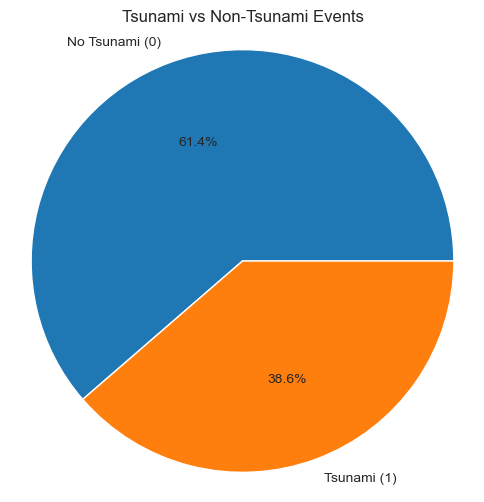

In [2006]:
plt.figure(figsize=(6,6))
plt.pie(y.value_counts(), labels=['No Tsunami (0)', 'Tsunami (1)'], autopct='%1.1f%%')
plt.title('Tsunami vs Non-Tsunami Events')
plt.axis('equal')
plt.show()

This pie chart clearly shows the imbalance in the dataset with a large majority of non-tsunami events. Its important we keep the class imbalance in mind when building our predictive models as it can impact performance as the model may be biased towards predicting the majority class without intervention (e.g. using class weighting, resampling techniques, etc.).